Using data dir: .
train: (10000, 18) test: (1000, 17)
target mean: 0.35

=== Leakage diagnostics ===
Train duplicate IDs: 0
Test duplicate IDs: 0
Exact feature-row overlap train/test: 0

Top numeric single-feature AUCs (watch if near 1.0):


,feature,single_feature_auc
0,duration,0.808850
1,previous,0.600885
2,pdays,0.591282
3,balance,0.586831
4,campaign,0.576892
5,day,0.527893
6,id,0.509915
7,age,0.505538


Total features: 41 | Categorical: 15

===== Running seed 42 =====
Seed 42 Fold 1 | Cat AUC=0.933171 | LGB AUC=0.929113
Seed 42 Fold 2 | Cat AUC=0.930704 | LGB AUC=0.924453
Seed 42 Fold 3 | Cat AUC=0.937849 | LGB AUC=0.936257
Seed 42 Fold 4 | Cat AUC=0.933007 | LGB AUC=0.930715
Seed 42 Fold 5 | Cat AUC=0.938174 | LGB AUC=0.933733

===== Running seed 2024 =====
Seed 2024 Fold 1 | Cat AUC=0.933646 | LGB AUC=0.931075
Seed 2024 Fold 2 | Cat AUC=0.925030 | LGB AUC=0.920537
Seed 2024 Fold 3 | Cat AUC=0.937901 | LGB AUC=0.935158
Seed 2024 Fold 4 | Cat AUC=0.938558 | LGB AUC=0.934635
Seed 2024 Fold 5 | Cat AUC=0.938365 | LGB AUC=0.934246

===== Running seed 3407 =====
Seed 3407 Fold 1 | Cat AUC=0.933115 | LGB AUC=0.931190
Seed 3407 Fold 2 | Cat AUC=0.931436 | LGB AUC=0.925974
Seed 3407 Fold 3 | Cat AUC=0.935474 | LGB AUC=0.931193
Seed 3407 Fold 4 | Cat AUC=0.930357 | LGB AUC=0.926302
Seed 3407 Fold 5 | Cat AUC=0.939903 | LGB AUC=0.938680


,cat_auc,lgb_auc
seed,,
42,0.934581,0.930854
2024,0.934700,0.931130
3407,0.934057,0.930668



Overall mean-by-fold:


,count,mean,std,min,25%,50%,75%,max
cat_auc,15.0,0.934446,0.004098,0.925030,0.932221,0.933646,0.938037,0.939903
lgb_auc,15.0,0.930884,0.004916,0.920537,0.927708,0.931190,0.934441,0.938680



OOF CatBoost AUC: 0.935371
OOF LightGBM AUC: 0.932283
OOF Rank-Blend AUC: 0.935451 | best Cat weight=0.89


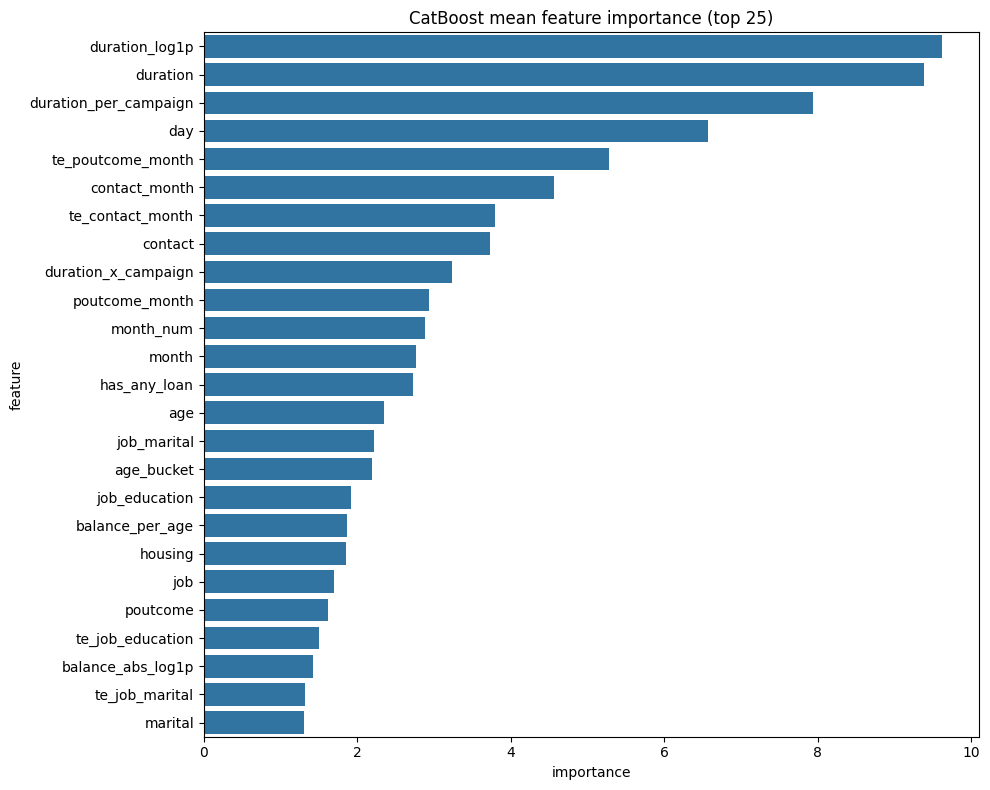

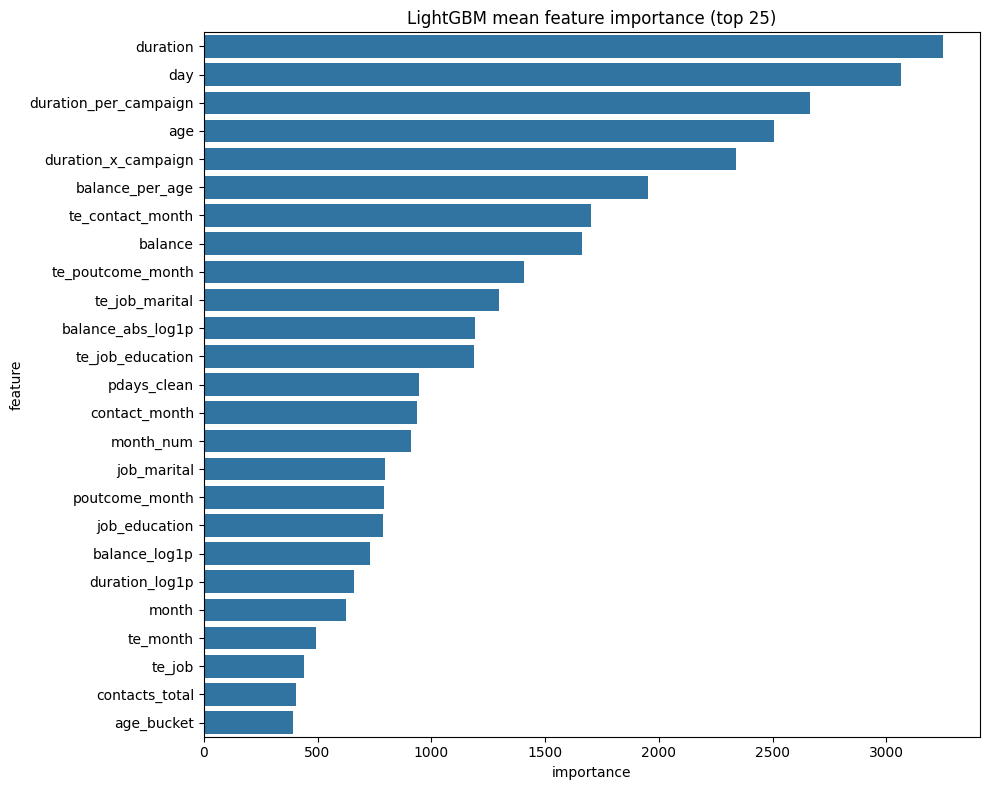

,feature,importance
15,duration_log1p,9.616121
14,duration,9.388962
16,duration_per_campaign,7.934452
12,day,6.576704
51,te_poutcome_month,5.274743
10,contact_month,4.565882
42,te_contact_month,3.794805
9,contact,3.732173
17,duration_x_campaign,3.236177
36,poutcome_month,2.934619


,feature,importance
14,duration,3248.533333
12,day,3065.400000
16,duration_per_campaign,2662.533333
0,age,2507.266667
17,duration_x_campaign,2339.400000
5,balance_per_age,1952.200000
42,te_contact_month,1700.666667
2,balance,1662.800000
51,te_poutcome_month,1405.733333
46,te_job_marital,1298.000000



Saved files:
- oof_predictions.csv
- submission_catboost.csv
- submission_lightgbm.csv
- submission_rank_blend.csv

Shuffled-target leakage sanity AUC: 0.5074 (expected ~0.50)


In [1]:

# =========================================================
# Bank Marketing ROC-AUC pipeline (Kaggle-ready)
# =========================================================
# Optional (if image misses deps):
# !pip -q install catboost lightgbm seaborn

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder

from catboost import CatBoostClassifier
import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500)
np.random.seed(42)

# -----------------------------
# Config
# -----------------------------
TARGET = "Subscribed"
ID_COL = "id"

N_SPLITS = 5
SEEDS = [42, 2024, 3407]  # robust repeated CV via multiple stratified seeds
EARLY_STOP = 250

TE_COLS = [
    "job", "marital", "education", "contact", "month", "poutcome",
    "age_bucket", "job_education", "job_marital", "contact_month",
    "poutcome_month", "loan_default"
]
TE_SMOOTHING = 30.0

CAT_PARAMS = dict(
    iterations=4500,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=7,
    random_strength=1.0,
    bagging_temperature=0.2,
    bootstrap_type="Bayesian",
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    allow_writing_files=False,
    verbose=False
)

LGB_PARAMS = dict(
    n_estimators=5000,
    learning_rate=0.015,
    num_leaves=96,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_alpha=0.3,
    reg_lambda=2.0,
    objective="binary",
    class_weight="balanced",
    n_jobs=-1,
    verbosity=-1
)

# -----------------------------
# Data loading
# -----------------------------
def resolve_data_dir():
    candidates = [
        "/kaggle/input/fiicode-2026-ai-competition",
        "/kaggle/input/competitions/fiicode-2026-ai-competition",
        "/kaggle/input/bank-marketing",
        ".",
    ]
    for c in candidates:
        p = Path(c)
        if (p / "train.csv").exists() and (p / "test.csv").exists():
            return p
    raise FileNotFoundError("Could not find train.csv/test.csv in known paths.")

DATA_DIR = resolve_data_dir()
print("Using data dir:", DATA_DIR)

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

print("train:", train_raw.shape, "test:", test_raw.shape)
print("target mean:", train_raw[TARGET].mean())

# -----------------------------
# Leakage diagnostics
# -----------------------------
def leakage_report(train_df, test_df, target_col):
    print("\n=== Leakage diagnostics ===")
    print("Train duplicate IDs:", train_df[ID_COL].duplicated().sum())
    print("Test duplicate IDs:", test_df[ID_COL].duplicated().sum())

    # Exact row overlap between train features and test features
    tr_feat = train_df.drop(columns=[target_col]).copy()
    te_feat = test_df.copy()
    tr_hash = pd.util.hash_pandas_object(tr_feat, index=False)
    te_hash = pd.util.hash_pandas_object(te_feat, index=False)
    overlap = np.intersect1d(tr_hash.values, te_hash.values).size
    print("Exact feature-row overlap train/test:", overlap)

    y = train_df[target_col].astype(int)
    suspicious = []

    for col in tr_feat.columns:
        s = tr_feat[col]
        if pd.api.types.is_numeric_dtype(s) and s.nunique() > 1:
            try:
                auc_pos = roc_auc_score(y, s.rank(pct=True))
                auc_neg = roc_auc_score(y, (-s).rank(pct=True))
                auc = max(auc_pos, auc_neg)
                suspicious.append((col, auc))
            except Exception:
                pass

    suspicious = sorted(suspicious, key=lambda x: x[1], reverse=True)[:10]
    print("\nTop numeric single-feature AUCs (watch if near 1.0):")
    display(pd.DataFrame(suspicious, columns=["feature", "single_feature_auc"]))

leakage_report(train_raw, test_raw, TARGET)

# -----------------------------
# Feature engineering
# -----------------------------
MONTH_MAP = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # Temporal + contact state
    d["month_num"] = d["month"].map(MONTH_MAP).fillna(0).astype(int)
    d["pdays_was_missing"] = (d["pdays"] == -1).astype(int)
    d["pdays_clean"] = d["pdays"].replace(-1, 999)

    # Core transforms
    d["duration_log1p"] = np.log1p(d["duration"])
    d["balance_log1p"] = np.log1p(np.clip(d["balance"], 0, None))
    d["balance_abs_log1p"] = np.log1p(np.abs(d["balance"]))
    d["campaign_log1p"] = np.log1p(d["campaign"])
    d["previous_log1p"] = np.log1p(np.clip(d["previous"], 0, None))
    d["pdays_log1p"] = np.log1p(d["pdays_clean"])

    # Ratios / interactions
    d["contacts_total"] = d["campaign"] + d["previous"]
    d["duration_per_campaign"] = d["duration"] / (d["campaign"] + 1)
    d["balance_per_age"] = d["balance"] / (d["age"] + 1)
    d["previous_per_campaign"] = d["previous"] / (d["campaign"] + 1)
    d["campaign_x_previous"] = d["campaign"] * d["previous"]
    d["duration_x_campaign"] = d["duration"] * d["campaign"]

    # Business flags
    d["has_any_loan"] = ((d["housing"] == "yes") | (d["loan"] == "yes")).astype(int)
    d["is_default"] = (d["default"] == "yes").astype(int)
    d["was_contacted_before"] = (d["pdays"] != -1).astype(int)
    d["is_cellular"] = (d["contact"] == "cellular").astype(int)

    # Buckets
    d["age_bucket"] = pd.cut(
        d["age"],
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
    ).astype(str)

    # Categorical interactions
    d["job_education"] = d["job"].astype(str) + "__" + d["education"].astype(str)
    d["job_marital"] = d["job"].astype(str) + "__" + d["marital"].astype(str)
    d["contact_month"] = d["contact"].astype(str) + "__" + d["month"].astype(str)
    d["poutcome_month"] = d["poutcome"].astype(str) + "__" + d["month"].astype(str)
    d["loan_default"] = d["loan"].astype(str) + "__" + d["default"].astype(str)

    return d

train_fe = add_features(train_raw)
test_fe = add_features(test_raw)

y = train_fe[TARGET].astype(int)
X = train_fe.drop(columns=[TARGET, ID_COL]).copy()
X_test = test_fe.drop(columns=[ID_COL]).copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for c in cat_cols:
    X[c] = X[c].astype(str).fillna("missing")
    X_test[c] = X_test[c].astype(str).fillna("missing")

print("Total features:", X.shape[1], "| Categorical:", len(cat_cols))

# -----------------------------
# Fold-safe target encoding
# -----------------------------
def add_fold_target_encoding(X_tr, X_va, X_te, y_tr, cols, smoothing=20.0):
    X_tr = X_tr.copy()
    X_va = X_va.copy()
    X_te = X_te.copy()

    global_mean = float(y_tr.mean())
    tmp = X_tr.copy()
    tmp["_y_"] = y_tr.values

    for col in cols:
        if col not in X_tr.columns:
            continue

        stats = tmp.groupby(col)["_y_"].agg(["mean", "count"])
        enc = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
        te_name = f"te_{col}"

        X_tr[te_name] = X_tr[col].map(enc).fillna(global_mean).astype(float)
        X_va[te_name] = X_va[col].map(enc).fillna(global_mean).astype(float)
        X_te[te_name] = X_te[col].map(enc).fillna(global_mean).astype(float)

    return X_tr, X_va, X_te

def encode_for_lgb(X_tr, X_va, X_te, categorical_cols):
    X_tr = X_tr.copy()
    X_va = X_va.copy()
    X_te = X_te.copy()

    if len(categorical_cols) > 0:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_tr[categorical_cols] = enc.fit_transform(X_tr[categorical_cols])
        X_va[categorical_cols] = enc.transform(X_va[categorical_cols])
        X_te[categorical_cols] = enc.transform(X_te[categorical_cols])

    return X_tr, X_va, X_te

# -----------------------------
# CV training per seed
# -----------------------------
def run_one_seed(seed, X, y, X_test, cat_cols):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    oof_cat = np.zeros(len(X), dtype=float)
    oof_lgb = np.zeros(len(X), dtype=float)
    test_cat = np.zeros(len(X_test), dtype=float)
    test_lgb = np.zeros(len(X_test), dtype=float)

    cat_fi_rows = []
    lgb_fi_rows = []
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X.iloc[tr_idx].copy()
        X_va = X.iloc[va_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_va = y.iloc[va_idx].copy()

        # Fold-safe target encoding
        X_tr_te, X_va_te, X_te_te = add_fold_target_encoding(
            X_tr, X_va, X_test, y_tr, TE_COLS, smoothing=TE_SMOOTHING
        )

        # --- CatBoost (primary) ---
        cat_idx = [X_tr_te.columns.get_loc(c) for c in cat_cols]
        cat_model = CatBoostClassifier(**CAT_PARAMS, random_seed=seed + fold)

        cat_model.fit(
            X_tr_te, y_tr,
            cat_features=cat_idx,
            eval_set=(X_va_te, y_va),
            use_best_model=True,
            early_stopping_rounds=EARLY_STOP
        )

        p_va_cat = cat_model.predict_proba(X_va_te)[:, 1]
        p_te_cat = cat_model.predict_proba(X_te_te)[:, 1]

        oof_cat[va_idx] = p_va_cat
        test_cat += p_te_cat / N_SPLITS

        cat_fi = pd.DataFrame({
            "feature": X_tr_te.columns,
            "importance": cat_model.get_feature_importance(),
            "fold": fold,
            "seed": seed
        })
        cat_fi_rows.append(cat_fi)

        # --- LightGBM (secondary) ---
        X_tr_lgb, X_va_lgb, X_te_lgb = encode_for_lgb(X_tr_te, X_va_te, X_te_te, cat_cols)
        lgb_model = lgb.LGBMClassifier(**LGB_PARAMS, random_state=seed + fold)

        lgb_model.fit(
            X_tr_lgb, y_tr,
            eval_set=[(X_va_lgb, y_va)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)]
        )

        p_va_lgb = lgb_model.predict_proba(X_va_lgb)[:, 1]
        p_te_lgb = lgb_model.predict_proba(X_te_lgb)[:, 1]

        oof_lgb[va_idx] = p_va_lgb
        test_lgb += p_te_lgb / N_SPLITS

        lgb_fi = pd.DataFrame({
            "feature": X_tr_te.columns,
            "importance": lgb_model.feature_importances_,
            "fold": fold,
            "seed": seed
        })
        lgb_fi_rows.append(lgb_fi)

        fold_cat_auc = roc_auc_score(y_va, p_va_cat)
        fold_lgb_auc = roc_auc_score(y_va, p_va_lgb)
        fold_rows.append({
            "seed": seed,
            "fold": fold,
            "cat_auc": fold_cat_auc,
            "lgb_auc": fold_lgb_auc
        })
        print(f"Seed {seed} Fold {fold} | Cat AUC={fold_cat_auc:.6f} | LGB AUC={fold_lgb_auc:.6f}")

    return {
        "oof_cat": oof_cat,
        "oof_lgb": oof_lgb,
        "test_cat": test_cat,
        "test_lgb": test_lgb,
        "cat_fi": pd.concat(cat_fi_rows, ignore_index=True),
        "lgb_fi": pd.concat(lgb_fi_rows, ignore_index=True),
        "fold_scores": pd.DataFrame(fold_rows)
    }

# -----------------------------
# Run multi-seed CV
# -----------------------------
seed_outputs = []
for seed in SEEDS:
    print(f"\n===== Running seed {seed} =====")
    seed_outputs.append(run_one_seed(seed, X, y, X_test, cat_cols))

oof_cat = np.mean(np.vstack([o["oof_cat"] for o in seed_outputs]), axis=0)
oof_lgb = np.mean(np.vstack([o["oof_lgb"] for o in seed_outputs]), axis=0)
test_cat = np.mean(np.vstack([o["test_cat"] for o in seed_outputs]), axis=0)
test_lgb = np.mean(np.vstack([o["test_lgb"] for o in seed_outputs]), axis=0)

all_fold_scores = pd.concat([o["fold_scores"] for o in seed_outputs], ignore_index=True)
display(all_fold_scores.groupby("seed")[["cat_auc", "lgb_auc"]].mean())
print("\nOverall mean-by-fold:")
display(all_fold_scores[["cat_auc", "lgb_auc"]].describe().T)

# -----------------------------
# Rank-based blending (AUC-aligned)
# -----------------------------
def rank_pct(arr):
    return pd.Series(arr).rank(method="average", pct=True).to_numpy()

oof_cat_rank = rank_pct(oof_cat)
oof_lgb_rank = rank_pct(oof_lgb)
test_cat_rank = rank_pct(test_cat)
test_lgb_rank = rank_pct(test_lgb)

w_grid = np.linspace(0, 1, 101)
best_w, best_auc = None, -1.0

for w in w_grid:
    blended = w * oof_cat_rank + (1 - w) * oof_lgb_rank
    auc = roc_auc_score(y, blended)
    if auc > best_auc:
        best_auc = auc
        best_w = w

oof_blend = best_w * oof_cat_rank + (1 - best_w) * oof_lgb_rank
test_blend = best_w * test_cat_rank + (1 - best_w) * test_lgb_rank

cat_auc = roc_auc_score(y, oof_cat)
lgb_auc = roc_auc_score(y, oof_lgb)
blend_auc = roc_auc_score(y, oof_blend)

print(f"\nOOF CatBoost AUC: {cat_auc:.6f}")
print(f"OOF LightGBM AUC: {lgb_auc:.6f}")
print(f"OOF Rank-Blend AUC: {blend_auc:.6f} | best Cat weight={best_w:.2f}")

# -----------------------------
# Feature importance visualization
# -----------------------------
all_cat_fi = pd.concat([o["cat_fi"] for o in seed_outputs], ignore_index=True)
all_lgb_fi = pd.concat([o["lgb_fi"] for o in seed_outputs], ignore_index=True)

def plot_top_importance(fi_df, title, top_n=25):
    agg = (
        fi_df.groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    plt.figure(figsize=(10, 8))
    sns.barplot(data=agg, y="feature", x="importance", orient="h")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return agg

top_cat = plot_top_importance(all_cat_fi, "CatBoost mean feature importance (top 25)", top_n=25)
top_lgb = plot_top_importance(all_lgb_fi, "LightGBM mean feature importance (top 25)", top_n=25)

display(top_cat.head(20))
display(top_lgb.head(20))

# -----------------------------
# OOF and submission artifacts
# -----------------------------
oof_df = pd.DataFrame({
    ID_COL: train_raw[ID_COL],
    "y_true": y.values,
    "oof_catboost": oof_cat,
    "oof_lightgbm": oof_lgb,
    "oof_rank_blend": oof_blend
})
oof_df.to_csv("oof_predictions.csv", index=False)

sub_cat = pd.DataFrame({ID_COL: test_raw[ID_COL], TARGET: test_cat})
sub_lgb = pd.DataFrame({ID_COL: test_raw[ID_COL], TARGET: test_lgb})
sub_blend = pd.DataFrame({ID_COL: test_raw[ID_COL], TARGET: test_blend})

sub_cat.to_csv("submission_catboost.csv", index=False)
sub_lgb.to_csv("submission_lightgbm.csv", index=False)
sub_blend.to_csv("submission_rank_blend.csv", index=False)

print("\nSaved files:")
print("- oof_predictions.csv")
print("- submission_catboost.csv")
print("- submission_lightgbm.csv")
print("- submission_rank_blend.csv")

# -----------------------------
# Extra leakage sanity: shuffled-target test
# should be ~0.50 AUC
# -----------------------------
def shuffled_target_test(X, y, cat_cols, seed=123):
    y_shuffled = y.sample(frac=1.0, random_state=seed).to_numpy()
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    aucs = []

    for tr_idx, va_idx in skf.split(X, y):
        Xt = X.iloc[tr_idx].copy()
        Xv = X.iloc[va_idx].copy()

        # cheap encode for fast check
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        Xt[cat_cols] = enc.fit_transform(Xt[cat_cols])
        Xv[cat_cols] = enc.transform(Xv[cat_cols])

        m = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=seed,
            verbosity=-1
        )
        m.fit(
            Xt, y_shuffled[tr_idx],
            eval_set=[(Xv, y_shuffled[va_idx])],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        p = m.predict_proba(Xv)[:, 1]
        aucs.append(roc_auc_score(y_shuffled[va_idx], p))

    return float(np.mean(aucs))

shuffle_auc = shuffled_target_test(X, y, cat_cols, seed=777)
print(f"\nShuffled-target leakage sanity AUC: {shuffle_auc:.4f} (expected ~0.50)")
